## Introduction
This is my personal study guide made while following Andrej Karpathy's makemore series. I'm planning to use the 'brainrot.txt' file as my data to implement basic language models from scratch that can generate brainrot words.

In [1]:
with open('brainrot_corpus.txt','r') as f:
    text = f.read()

In [2]:
words = text.split()
words = [w.lower() for w in words]
words[:10]

['crashout',
 'karen:',
 'bruh,',
 "it's",
 'giving',
 'rizz,',
 'grimace',
 'shake',
 'guy',
 'bro']

In [3]:
len(words)

205085

In [4]:
for w in words[:1]: # only the first word
    chs = ['<S>'] + list(w) + ['<E>'] # start and end character needed since the bigram predicts 1 character at a time
    for ch1,ch2 in  zip(chs,chs[1:]): # print 2 consecutive characters at a time
        print(ch1,ch2) # eg: emma will print em, mm,ma

<S> c
c r
r a
a s
s h
h o
o u
u t
t <E>


## Data Visualization for Bigrams
A tuple of 2 consecutive characters in this use case is called a bigram. First we need to make a dictionary of all bigrams in our dataset and count the number of times they appear, giving us valuable info: given a character c1, what is the most common appearing next character c2 immediately after.

In [5]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1 # add 1 to bigram count or if bigram not found in b then initialise to 0

In [6]:
# now we need to sort bigrams in order of most common
sorted(b.items(),key = lambda kv : -kv[1]) # b.items turns dictionary into nested tuple, with bigram at 0 and count at 1 and key function
# tells sorted to sort by the second element of the tuple ie the count in descending order (the - sign)

[(('e', '<E>'), 32976),
 (('<S>', 't'), 27023),
 (('t', 'h'), 25786),
 (('h', 'e'), 23517),
 (('<S>', 's'), 18357),
 (('d', '<E>'), 18130),
 (('<S>', 'a'), 17809),
 ((',', '<E>'), 17740),
 (('i', 'n'), 17126),
 (('<S>', 'g'), 17034),
 (('t', '<E>'), 16069),
 (('n', '<E>'), 12945),
 (('<S>', 'c'), 12774),
 (('<S>', 'f'), 11758),
 (('<S>', 'i'), 11707),
 (('s', '<E>'), 11235),
 (('r', 'a'), 11217),
 (('a', 'i'), 11189),
 (('.', '<E>'), 11033),
 (('<S>', 'm'), 10990),
 (('<S>', 'b'), 10712),
 (('a', 't'), 10203),
 (('i', 'd'), 10034),
 (('y', '<E>'), 9645),
 (('e', 'r'), 9606),
 (('r', 'o'), 9261),
 (('o', '<E>'), 9054),
 (('i', 't'), 9030),
 (('r', '<E>'), 9021),
 (('a', '<E>'), 8999),
 (('l', 'e'), 8820),
 (('e', 'd'), 8733),
 (('<S>', 'r'), 8601),
 (('<S>', 'd'), 8484),
 (('r', 'e'), 8473),
 (('<S>', 'w'), 8421),
 (('<S>', 'o'), 8368),
 (('o', 'u'), 7891),
 (('a', 'n'), 7848),
 (('<S>', 'n'), 7124),
 (('r', 'i'), 7015),
 (('a', 'l'), 6434),
 (('e', 'a'), 6433),
 (('a', 'r'), 6279),
 ((

## Basic Pytorch
We need basics of pytorch to train the model using 2D tensors

In [7]:
import torch

In [8]:
a = torch.zeros((3,5),dtype=torch.int)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [9]:
a[1,3] = 1
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

## Lookup Table
For Bigrams, we basically need a big lookup table. Bigrams have character level tokenization, meaning they predict the next character using the last character by seeing a giant lookup table and predicting the character which is most common to come after our latest character in our dataset.

In [10]:
# finding how many characters we have
chars = list(set(''.join(words)))
len(chars)

40

In [11]:
n = len(chars)

In [12]:
# We have 64 unique characters + 2 special chars for start and end tokens so our lookup table should be 66x66
N = torch.zeros((66,66),dtype=torch.int32)

In [13]:
# now we make encoding - decoding functions to convert a char to int
stoi = {s:i for i,s in enumerate(chars)}
stoi['<S>'] = 64
stoi['<E>'] = 65

In [14]:
itos = {i:s for i,s in enumerate(chars)}
itos[64] = '<S>'
itos[65] = '<E>'

In [15]:
# finally filling the lookup table
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

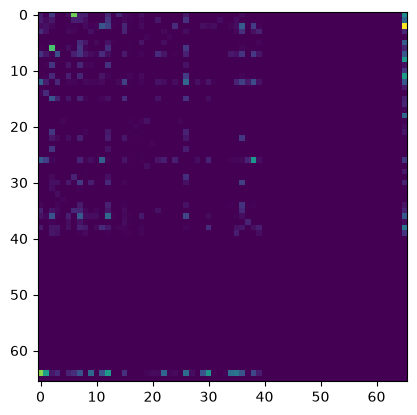

In [16]:
# visualizing this
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)
plt.show()

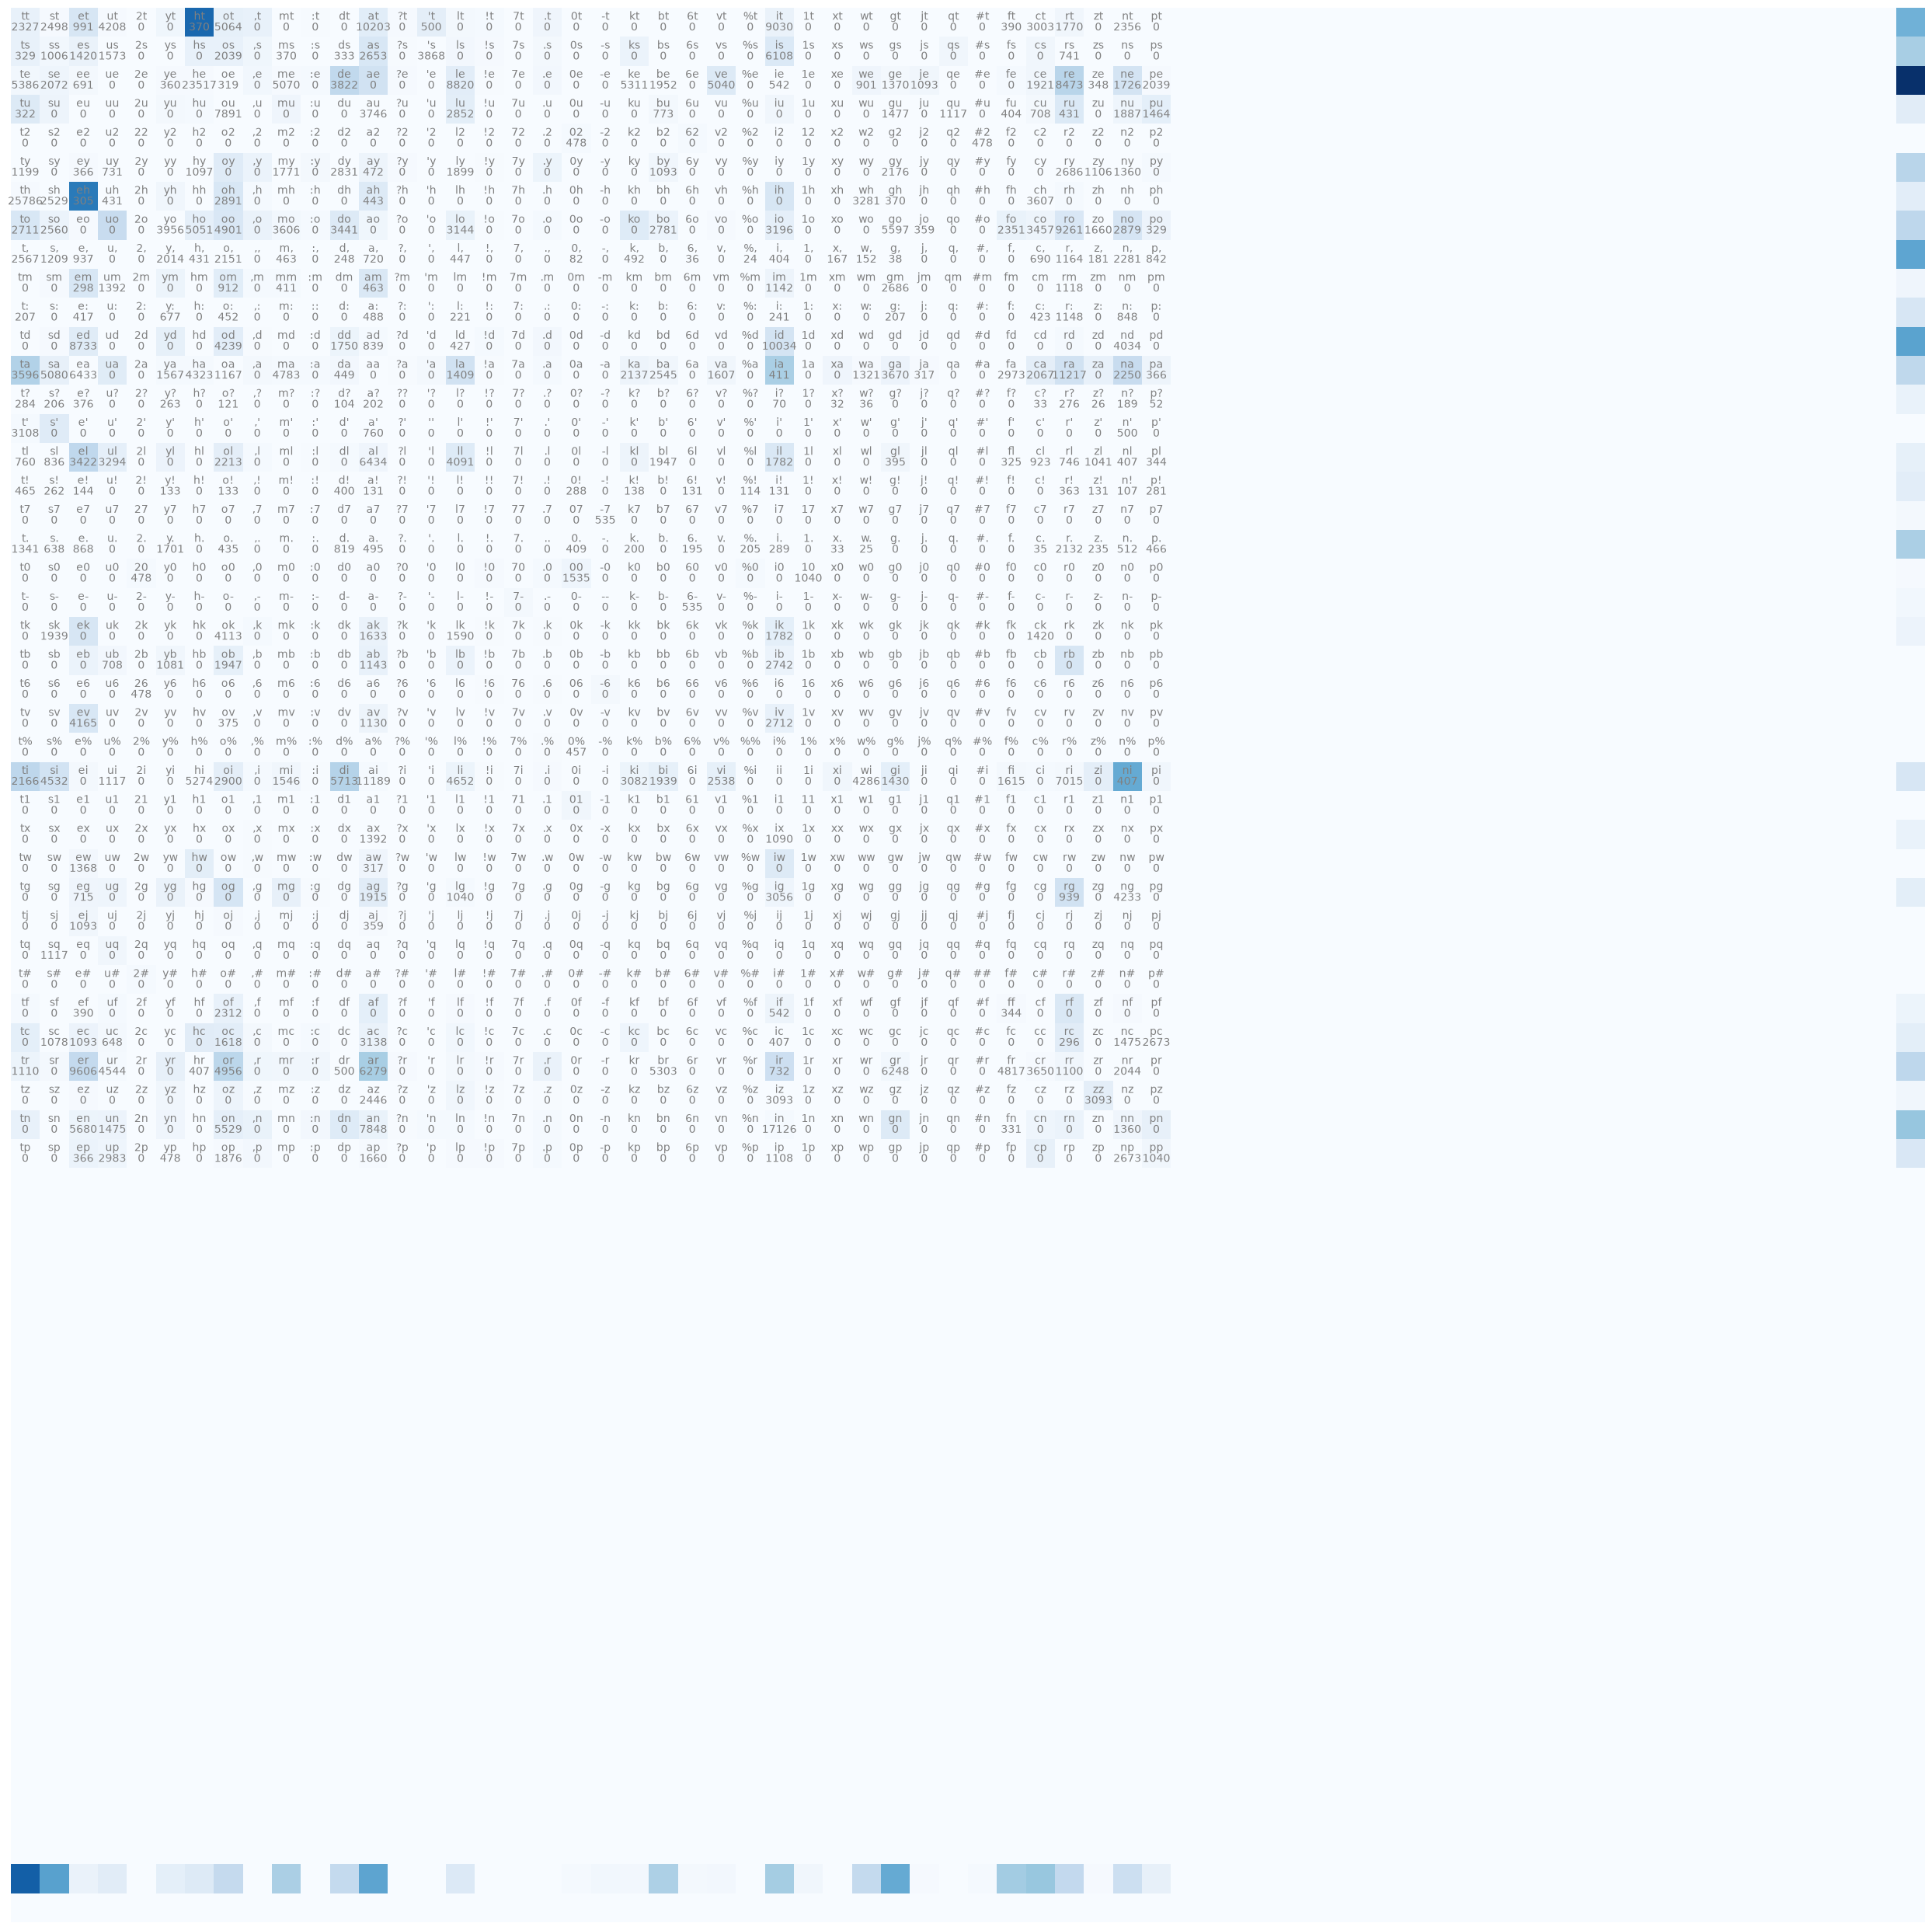

In [17]:
plt.figure(figsize=(32,32))
plt.imshow(N,cmap='Blues')
for i in range(n):
    for j in range(n):
        chstr = itos[i] + itos[j]
        plt.text(i,j,chstr,ha='center',va='bottom',color='gray')
        plt.text(i,j,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off')
plt.show()

The above diagram shows us there is some inefficiency. It is not possible for any character to come after ```<E>``` or before ```<S>``` so their respective row/column are all 0. We can reduce this redundancy by only having one special character '.' that signifies end of a word.

In [18]:
# 64 chars + 1 special char
N = torch.zeros((n+1,n+1),dtype=torch.int32)

In [19]:
stio = {s:i for i,s in enumerate(chars)}
itos = {i:s for i,s in enumerate(chars)}
stoi['.'] = n
itos[64] = '.'

In [20]:
for w in words:
    chs = ['.' ] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1

## Sampling 
Bigrams work by making a probability distribution of all the chars that could come next after a given char and sampling from this probability  distribution.

In [21]:
# first we create an example probability distribution and try to sample from it.
g = torch.Generator().manual_seed(2147483647) # generators are like seed so that given a seed, we always get the same sample
p = torch.rand(3,generator=g) # will distribute a list of 3 random numbers
p

tensor([0.7081, 0.3542, 0.1054])

In [22]:
# now to convert that list into a probability distribution we need that the sum of all elements should be 1
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [23]:
# now using the probability distribution, we will sample. Sampling basically works: the probability of index i being sampled is p[i]
torch.multinomial(p,generator=g,replacement=True, num_samples = 10)
# replacement=True means when an index is sampled, it will not be removed and will be considered again for sampling
# num_samples is the number of samples it generates based on the probability distribution

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0])

In [24]:
# So now we will implement sampling into our N lookup table
# the idea is to sample given the char '.' and keep sampling until '.' appears again
# let's start with sampling 10 words
for i in range(10):
    ix = n # index of '.'
    out = []
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p,generator=g,num_samples=1,replacement=True).item()
        if ix == n:
            break
        out.append(itos[ix])
    w = ''.join(out)
    print(w)

or
molg
whaulood
gro
dol
wix
s

t
faloungrosk,


In [25]:
# the above words were samples using the probability distribution from our data, Bigrams in general are pretty inaccurate
# Here are what the words would look like if instead of learning probability distribution from data, we sample randomly
for i in range(10):
    ix = n
    out = []
    while True:
        p = torch.ones(n+1) / float(n+1)
        ix = torch.multinomial(p,generator=g,num_samples=1,replacement=True).item()
        if ix == n:
            break
        out.append(itos[ix])
    w = ''.join(out)
    print(w)

lzqb'l
lxxu%p#tcyr6wia0bk-bqg#pg:eksyycxc,2j2yk,7.rt1,!o#nd0v7uiyw:d'lvke
?ylb7ksc
#odm2#!guornk?xa:6!'-0.
hkafu1tz,n%?!a:wx%hq2v.ihjns2vgc-p7sh!f%y1ywic!,6'7v2f01.ek:i.,2krjyb-0rp!k7l1wp0ko!wye0yvx0!!h#s,m'1'sicd#ha
bkyvei1lnnubjm-b?:aohs?njp:%j?sdbc7ayhm%u,-pdo.?#tk,#k:2cmyk1e%#zel.fyrvjyvx???#2nwu#':wmci.
6kbf7u2hki!nrtbug.yh-1c2p0,p.uujc:.#,jlum
7fe!y.:o,:sch!2',lhnvro:zugm:#?!?q:,u?
o%dmitmpylbze0%j#z2yh'2ul0-g6bqqtl?whq6#ckqf#i:mz'lp-?2o%djf#!.#nhh?.poikchoj#:7irfj7jylz:un
'mmg1x.fa1gkmj,'.7'gcdj-0.j?


One inefficiency we have so far is that at each iteration we take the sum of a row in N and then calculate probability distribution. This causes a lot of redundancy and we end up calculating the probability distribution for the same row multiple times. Hence, one way to fix that would be to create a matrix P that is filled with the probability distribution itself.

In [26]:
N.shape

torch.Size([41, 41])

In [27]:
# We need a 65x1 tensor containing the sum of all 65 rows.
P = N.float() # copy of N
# P = P / P.sum(1,keepdim=True), same thing as below just creates a new tensor and wastes memory instead of inplace
P /= P.sum(1,keepdim=True)

In [28]:
P.shape

torch.Size([41, 41])

In [29]:
P[0].sum()

tensor(1.)

In the above codeblock, if we had done just `P.sum()` it would have given us a single integer containing sum of all values in the matrix.
`P.sum(0)` gives us a 1x65 tensor containing a row vector which is the sum of all rows, we want a vector which is sum of all columns (hence for each row, we want a value that is the sum of all values in that row) of shape 65x1. `keepdim=True`preserves the original dimensionality by only reducing the dimension across which we sum to 1 ie 65x65 becomes 65x1 instead of a 1D array with 65 elements. 
In `P / P.sum(1,keepdim=True)`, how are we able to divide a 65x65 matrix by a 65x1 ? Division among torch vectors follows **Broadcasting Rules** meaning in both, either a dimension is exactly the same or one of them is 1. Internally, PyTorch creates 65 copies of the 65x1 tensor and joins them making a 65x65 matrix and then divides each element in P with the respective element in this matrix which works for us because in any given row in this new matrix, all elements of that row are the same (sum of that original row) which we divide to the original elements giving us the distribution.

In [30]:
for i in range(10):
    ix = n
    out = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p,generator=g,num_samples=1,replacement=True).item()
        if ix==n:
            break
        out.append(itos[ix])
    w = ''.join(out)
    print(w)

vitheanderimoitherly
t,
t

o,
whokin:
dit
t
frlup
it'sithinthe


## Importance of Broadcasting Rules
Broadcasting rules are really important for tensor multiplication and division and if not taken care of, can introduce really subtle hard to catch bugs. Eg: What if we didn't keep `keepdim=True` in the above code.

In [31]:
P2 = N.float()
P2.sum(1).shape

torch.Size([41])

We now have a 1D array of 65 elements (the elements are same just the dimensions have changed).

In [32]:
P2 /= P2.sum(1)
P2[0].sum()

tensor(nan)

The above code runs but gives us NaN or sometimes even a number that isn't 1. Why is that ?
Just like when we tried to divide 65x65 by a 65x1 it made copies of 65x1 matrix internally to turn it into a 65x65, similarly when we divide 65x65 by \[65\] it by default turns it into 1x65 row vector and then makes copies of it to form a 65x65, thus the calculation takes place. The only difference being that we want the sum to be columnwise but here because of Broadcasting rules, it performs row wise sum by default even though we have dimension set as 1.

## Loss Function
We need a quantity/ a number to evaluate the quality of predictions of our number. This is the loss of the bigram.

In [34]:
for w in words[0:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2] # probability that ch2 comes after ch1
        print(f'{ch1}{ch2}:{prob:.4f}')

.c:0.0591
cr:0.1448
ra:0.1873
as:0.0342
sh:0.0652
ho:0.1152
ou:0.1134
ut:0.1570
t.:0.2497


We want these probabilities to be as close to 1 as possible (ideally) and so we can measure the loss function as the closeness to 1.
We measure loss for a word but the probabilities are characterwise. So Likelihood of a word = product of probabilities of consecutive characters coming after each other. Hence the more the likelihood, the better but multiplying small probabilities increases precision error so instead we use log likehood = log(a*\b\*c) = log(a) + log(b) + log(c) where a,b,c are consecutive char probabilities. A probability of 1 has log likelihood of 0 and as probability reduces to 0, log approaches $-\inf$. Hence the more the log likelihood the better. But a loss function is the one which is better the less it is. So we use negative loss likelihood, meaning more accuracy = less loss. However absolute log values can get extremely large so to normalize them we can divide it by total number of consecutive character pairs in that word.

In [35]:
for w in words[0:2]:
    negative_log_likelihood = 0
    num_pairs = 0
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        negative_log_likelihood += torch.log(prob)
        num_pairs += 1
    negative_log_likelihood = - negative_log_likelihood
    normalized_nll = negative_log_likelihood / num_pairs
    print(f'{w}:{normalized_nll}')

crashout:2.235305070877075
karen::2.6545374393463135


**GOAL:**
- Maximize likelihood of data w.r.t model parameters (statistical modeling)
- Maximize probability / likelihood of a word
- Maximize log likelihood
- Minimize negative log likelihood
- Minimize normalized negative log likelihood.